<div style="text-align: center;">

# Robotics and its Application (AI352) | Assignment 3

## Workspace Analysis for Different Coordinate Systems

---

**Student Name:** *Naishadh Rana*

**Roll No:** U23CS014

---

</div>

## Part A: 2R Planar Robot - Circular Trajectory Animation

**Joint Type Notation:**
| Symbol | Full Form | Motion | Example |
|--------|-----------|--------|---------|
| **R** | Revolute | Rotation | Door hinge |
| **P** | Prismatic | Linear slide | Drawer |

We command the end-effector along a circle of radius $r$ within $[R_\text{inner}, R_\text{outer}]$ and compute joint angles by **closed-form IK**:
$$\theta_2 = \arccos\left(\frac{x^2+y^2 - L_1^2 - L_2^2}{2 L_1 L_2}\right)$$
$$\theta_1 = \operatorname{atan2}(y,x) - \operatorname{atan2}(L_2\sin\theta_2, L_1 + L_2\cos\theta_2)$$

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:

from matplotlib import animation
from IPython.display import HTML

def ik_2r(x, y, L1, L2, elbow='down'):
    d = (x**2 + y**2 - L1**2 - L2**2) / (2*L1*L2)
    d = np.clip(d, -1.0, 1.0)
    if elbow == 'down':
        t2 = np.arccos(d)
    else:
        t2 = -np.arccos(d)
    t1 = np.arctan2(y, x) - np.arctan2(L2*np.sin(t2), L1 + L2*np.cos(t2))
    return t1, t2

def animate_circle(L1=1.0, L2=1.0, r_ratio=0.6, T=6.0, fps=30, elbow='down'):
    R_out, R_in = L1+L2, abs(L1-L2)
    r = max(min(r_ratio*R_out, R_out*0.95), max(R_in*1.05, 1e-6))
    frames = int(T*fps)
    t = np.linspace(0, 2*np.pi, frames, endpoint=False)
    x = r*np.cos(t); y = r*np.sin(t)
    th1, th2 = ik_2r(x, y, L1, L2, elbow=elbow)

    fig = plt.figure(figsize=(6.5, 6.5))
    ax = plt.gca()
    ax.set_xlim(-(L1+L2)*1.1, (L1+L2)*1.1)
    ax.set_ylim(-(L1+L2)*1.1, (L1+L2)*1.1)
    ax.set_aspect('equal'); ax.grid(True)
    line, = ax.plot([], [], marker='o', lw=3)
    tip_path, = ax.plot([], [], lw=1)
    ax.add_patch(plt.Circle((0,0), L1+L2, fill=False, linestyle='--'))
    ax.add_patch(plt.Circle((0,0), abs(L1-L2), fill=False, linestyle='--'))
    ax.set_title('2R Arm Circular end-effector Trajectory')

    xs_path, ys_path = [], []

    def fk(theta1, theta2):
        x1 = L1*np.cos(theta1); y1 = L1*np.sin(theta1)
        x2 = x1 + L2*np.cos(theta1+theta2)
        y2 = y1 + L2*np.sin(theta1+theta2)
        return (0, x1, x2), (0, y1, y2)

    def init():
        line.set_data([], []); tip_path.set_data([], []); return line, tip_path

    def update(i):
        Xs, Ys = fk(th1[i], th2[i])
        xs_path.append(Xs[-1]); ys_path.append(Ys[-1])
        line.set_data(Xs, Ys)
        tip_path.set_data(xs_path, ys_path)
        return line, tip_path

    ani = animation.FuncAnimation(fig, update, frames=frames, init_func=init, interval=1000/fps, blit=True)
    plt.close(fig)
    return HTML(ani.to_jshtml())

# r_ratio range: [0,1]
animate_circle(L1=1.0, L2=1.0, r_ratio=0.7, T=5.0, fps=30, elbow='down')


<div style="text-align: center; max-width: 550px; margin: 0 auto;">

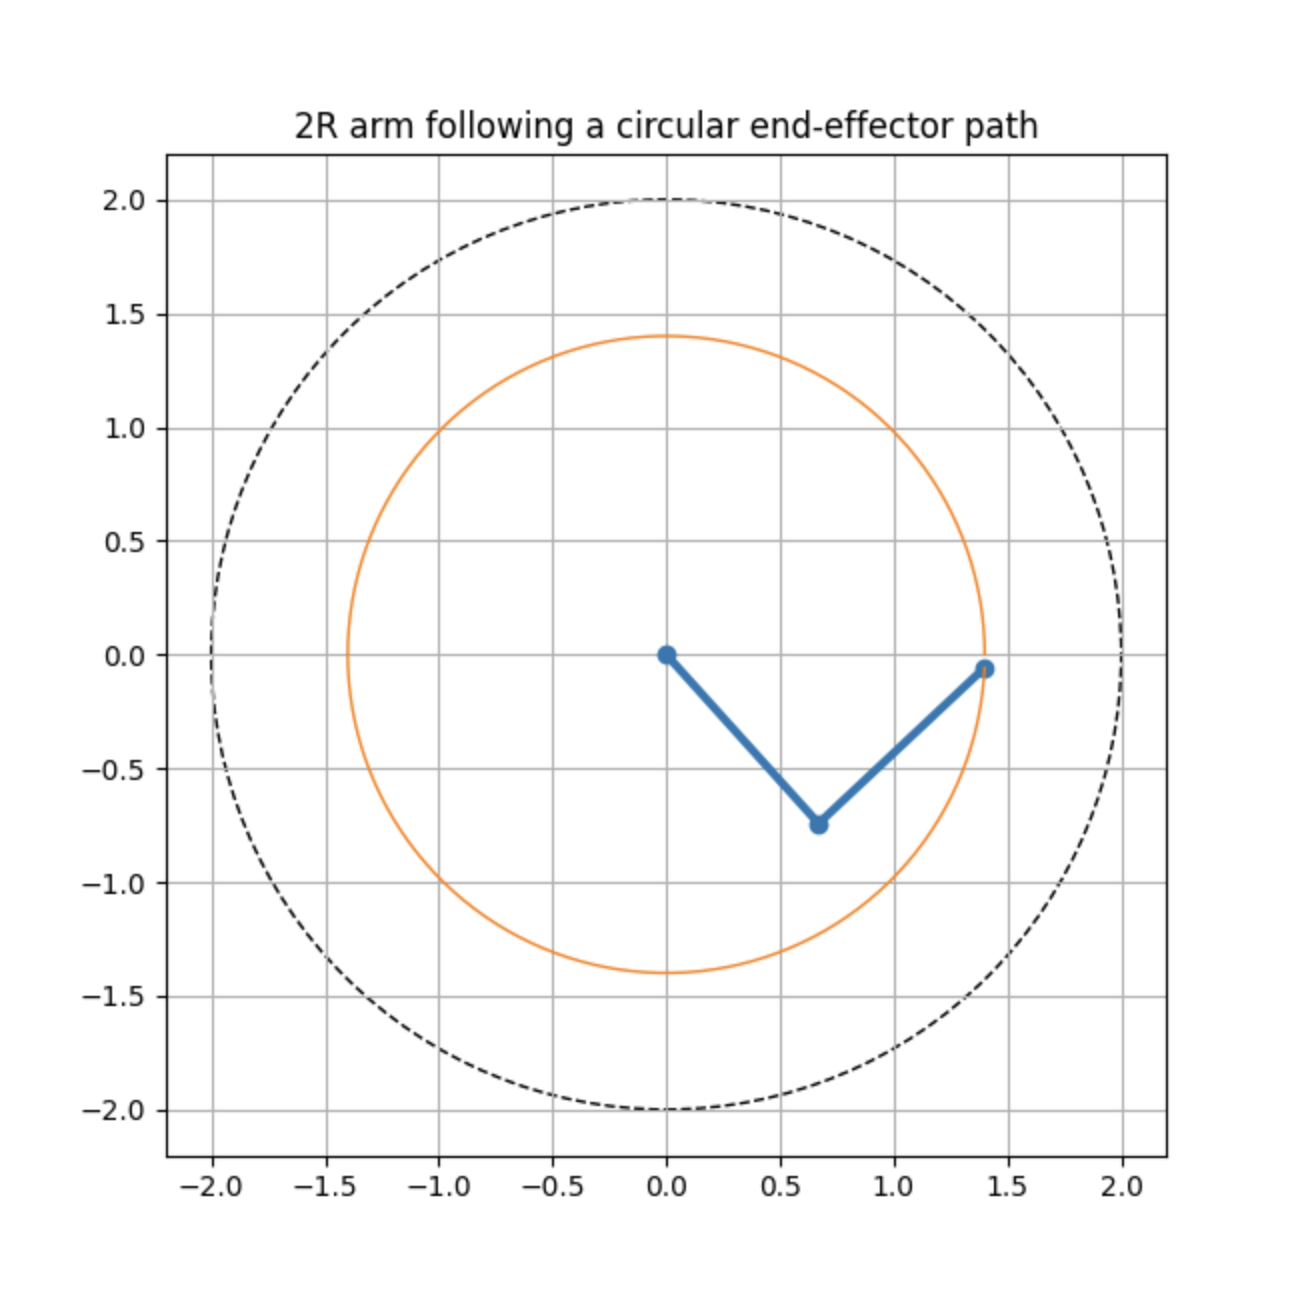

</div>

<div style="text-align: center;">

**Image 1:** 2R Circular trajectory

</div>


## Interactive GUI for nR planar

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import IntSlider, FloatSlider, VBox, HBox, Output
from IPython.display import display, clear_output

def fk_chain(angles, lengths):
    thetas = np.cumsum(angles)
    xs = np.cumsum(lengths * np.cos(thetas))
    ys = np.cumsum(lengths * np.sin(thetas))
    return np.concatenate([[0], xs]), np.concatenate([[0], ys])

def sample_workspace(lengths, samples=2000):
    n = len(lengths)
    th = np.random.uniform(-np.pi, np.pi, (samples, n))
    thetas = np.cumsum(th, axis=1)
    x = np.sum(lengths * np.cos(thetas), axis=1)
    y = np.sum(lengths * np.sin(thetas), axis=1)
    return x, y

n_slider = IntSlider(min=2, max=5, value=3, description='Links')
L1 = FloatSlider(min=0.3, max=2, step=0.1, value=1.0, description='L1')
L2 = FloatSlider(min=0.3, max=2, step=0.1, value=1.0, description='L2')
L3 = FloatSlider(min=0.3, max=2, step=0.1, value=0.8, description='L3')
L4 = FloatSlider(min=0.3, max=2, step=0.1, value=0.6, description='L4')
L5 = FloatSlider(min=0.3, max=2, step=0.1, value=0.5, description='L5')
t1 = FloatSlider(min=-np.pi, max=np.pi, step=0.1, value=0.5, description='θ1')
t2 = FloatSlider(min=-np.pi, max=np.pi, step=0.1, value=-0.3, description='θ2')
t3 = FloatSlider(min=-np.pi, max=np.pi, step=0.1, value=0.8, description='θ3')
t4 = FloatSlider(min=-np.pi, max=np.pi, step=0.1, value=0.4, description='θ4')
t5 = FloatSlider(min=-np.pi, max=np.pi, step=0.1, value=-0.2, description='θ5')

out = Output()

def update(_=None):
    n = n_slider.value
    lengths = np.array([L1.value, L2.value, L3.value, L4.value, L5.value][:n])
    angles = np.array([t1.value, t2.value, t3.value, t4.value, t5.value][:n])
    
    with out:
        clear_output(wait=True)
        fig, ax = plt.subplots(figsize=(8, 8))
        
        x_ws, y_ws = sample_workspace(lengths)
        ax.scatter(x_ws, y_ws, s=1, alpha=0.15, c='blue', label='Workspace')
        
        X, Y = fk_chain(angles, lengths)
        ax.plot(X, Y, 'ro-', lw=4, markersize=8, markeredgecolor='k', label='Robot Links')
        ax.plot(X[-1], Y[-1], 'g*', markersize=15, label='End Effector')
        
        ax.set_aspect('equal')
        ax.grid(True, alpha=0.3)
        ax.set_title(f'{n}R Planar Robot: Workspace & Config')
        ax.set_xlabel('X (m)')
        ax.set_ylabel('Y (m)')
        ax.legend(loc='upper right')
        
        rmax = np.sum(lengths) * 1.1
        ax.set_xlim(-rmax, rmax)
        ax.set_ylim(-rmax, rmax)
        
        display(fig)
        plt.close(fig)

widgets = [n_slider, L1, L2, L3, L4, L5, t1, t2, t3, t4, t5]
for w in widgets:
    w.observe(update, names='value')

display(VBox([
    HBox([n_slider]),
    HBox([L1, L2, L3, L4, L5]),
    HBox([t1, t2, t3, t4, t5]),
    out
]))

update()

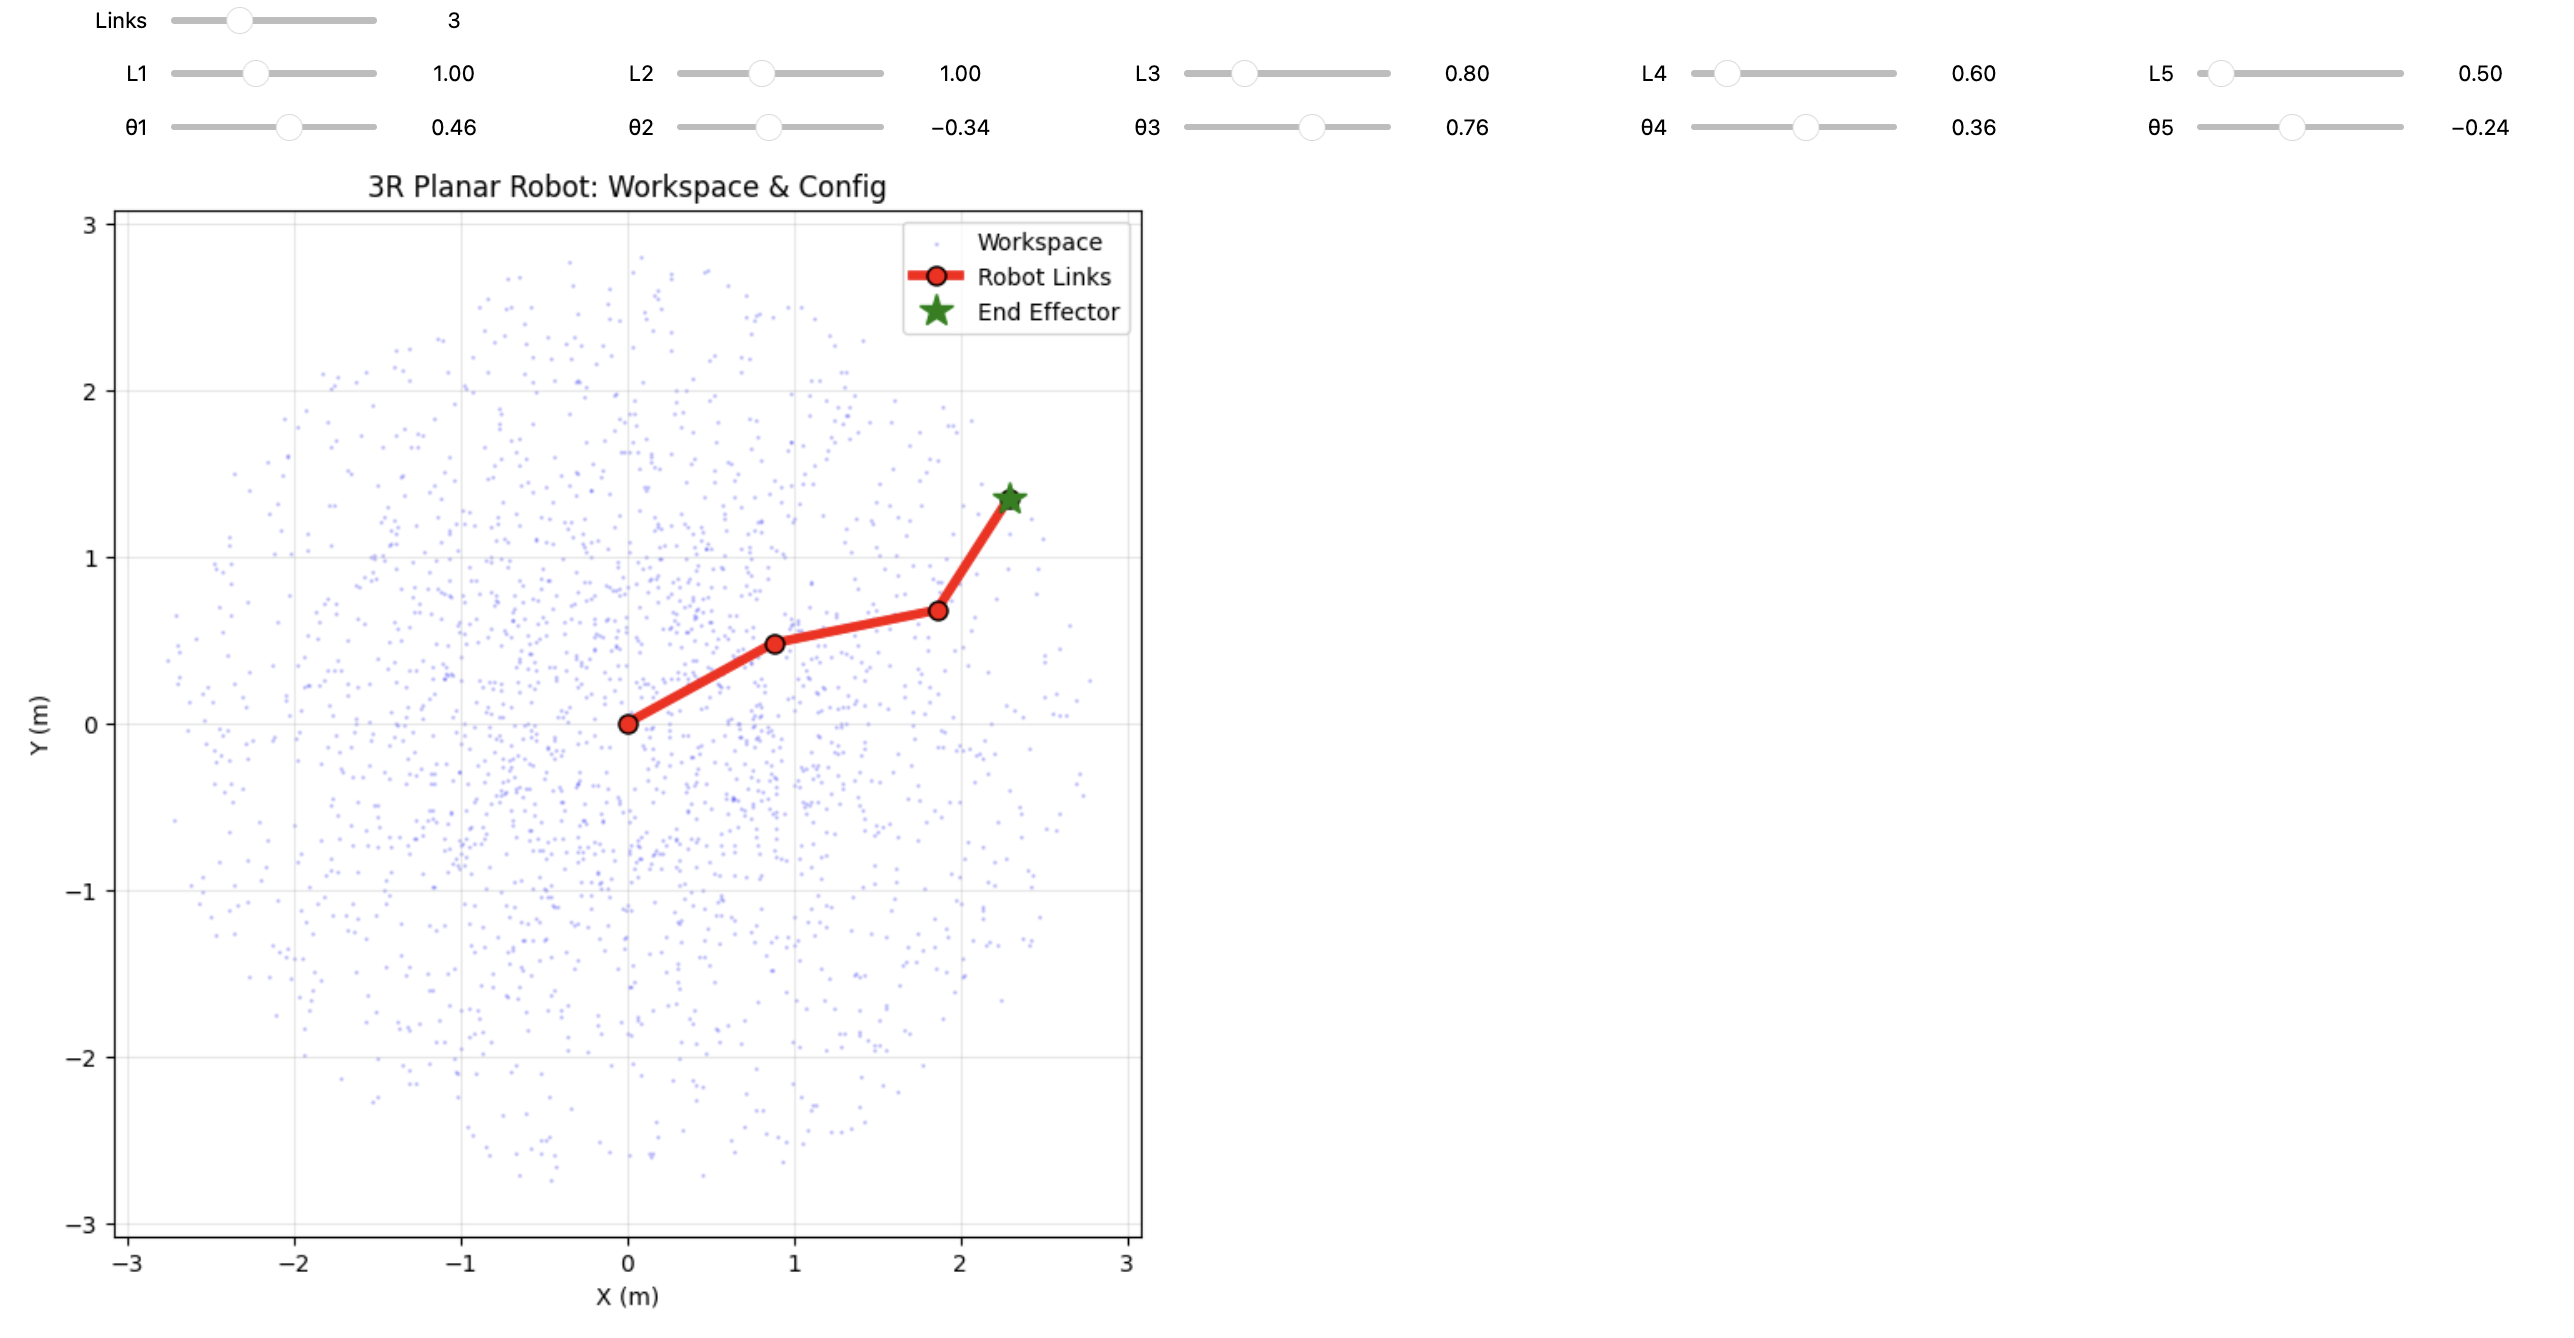
---

## Part B: Workspace Analysis of a 3R Planar Robot Arm

A **3R planar robot arm** has three revolute joints ($\theta_1, \theta_2, \theta_3$) and three rigid links ($L_1, L_2, L_3$). Unlike 2R, this robot has **kinematic redundancy** — multiple joint configurations can reach the same end-effector position.

**Forward Kinematics:**

$$x = L_1\cos(\theta_1) + L_2\cos(\theta_1+\theta_2) + L_3\cos(\theta_1+\theta_2+\theta_3)$$

$$y = L_1\sin(\theta_1) + L_2\sin(\theta_1+\theta_2) + L_3\sin(\theta_1+\theta_2+\theta_3)$$

**Workspace Boundaries:**
- **Outer radius:** $R_{\text{outer}} = L_1 + L_2 + L_3$ (all links aligned outward)
- **Inner radius:** $R_{\text{inner}} = |L_1 - L_2 - L_3|$ or $0$ if links can fold completely

In [ ]:
def compute_workspace_3r(L1, L2, L3, resolution=50):
    theta_range = np.linspace(-np.pi, np.pi, resolution)
    
    x_points = []
    y_points = []
    
    for t1 in theta_range:
        for t2 in theta_range:
            for t3 in theta_range:
                x = L1*np.cos(t1) + L2*np.cos(t1+t2) + L3*np.cos(t1+t2+t3)
                y = L1*np.sin(t1) + L2*np.sin(t1+t2) + L3*np.sin(t1+t2+t3)
                x_points.append(x)
                y_points.append(y)
    
    return np.array(x_points), np.array(y_points)

def compute_workspace_3r_monte_carlo(L1, L2, L3, samples=10000):
    t1 = np.random.uniform(-np.pi, np.pi, samples)
    t2 = np.random.uniform(-np.pi, np.pi, samples)
    t3 = np.random.uniform(-np.pi, np.pi, samples)
    
    x = L1*np.cos(t1) + L2*np.cos(t1+t2) + L3*np.cos(t1+t2+t3)
    y = L1*np.sin(t1) + L2*np.sin(t1+t2) + L3*np.sin(t1+t2+t3)
    return x, y

In [ ]:
L1, L2, L3 = 1.0, 0.8, 0.5

x_3r, y_3r = compute_workspace_3r_monte_carlo(L1, L2, L3, samples=15000)

fig, ax = plt.subplots(figsize=(8, 8))
distance = np.sqrt(x_3r**2 + y_3r**2)
scatter = ax.scatter(x_3r, y_3r, s=1, c=distance, cmap='viridis', alpha=0.5)

R_outer = L1 + L2 + L3
R_inner = abs(L1 - L2 - L3)
ax.add_patch(plt.Circle((0,0), R_outer, fill=False, linestyle='--', color='red', label=f'Outer: {R_outer}'))
if R_inner > 0.01:
    ax.add_patch(plt.Circle((0,0), R_inner, fill=False, linestyle='--', color='blue', label=f'Inner: {R_inner:.2f}'))

ax.set_xlabel('X Position (m)')
ax.set_ylabel('Y Position (m)')
ax.set_title(f'3R Robot Workspace: L1={L1}, L2={L2}, L3={L3}')
ax.axis('equal')
ax.grid(True, alpha=0.3)
ax.legend()
plt.colorbar(scatter, label='Reach Distance (m)')
plt.show()

<div style="text-align: center; max-width: 550px; margin: 0 auto;">

![3R WS](3R_WS.png)

</div>

<div style="text-align: center;">

**Image 3:** 3R Workspace

</div>

> **3R Circular Trajectory Animation**

For animating, we need inverse kinematics. Since 3R is redundant, we fix $\theta_3$ (e.g., keep end-effector orientation constant) and solve for $\theta_1, \theta_2$ using the 2R IK approach on the "virtual" 2-link formed by combining the last two links.
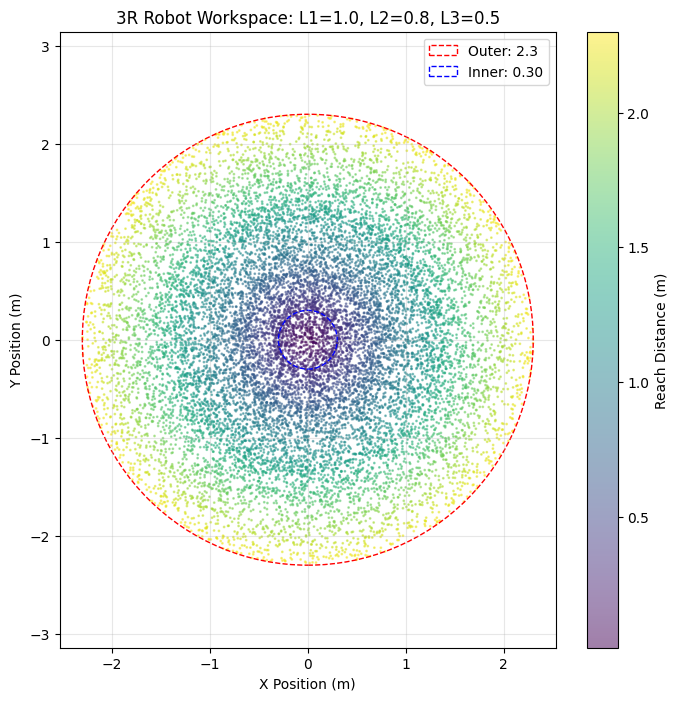

In [ ]:
def ik_3r_fixed_orientation(x, y, L1, L2, L3, phi=0):
    xw = x - L3 * np.cos(phi)
    yw = y - L3 * np.sin(phi)
    
    d = (xw**2 + yw**2 - L1**2 - L2**2) / (2*L1*L2)
    d = np.clip(d, -1.0, 1.0)
    
    t2 = np.arccos(d)
    t1 = np.arctan2(yw, xw) - np.arctan2(L2*np.sin(t2), L1 + L2*np.cos(t2))
    t3 = phi - t1 - t2
    
    return t1, t2, t3

def animate_3r_circle(L1=1.0, L2=0.8, L3=0.5, r_ratio=0.5, T=6.0, fps=30):
    R_out = L1 + L2 + L3
    r = r_ratio * R_out
    
    frames = int(T * fps)
    t = np.linspace(0, 2*np.pi, frames, endpoint=False)
    x_traj = r * np.cos(t)
    y_traj = r * np.sin(t)
    
    th1, th2, th3 = ik_3r_fixed_orientation(x_traj, y_traj, L1, L2, L3, phi=0)
    
    fig = plt.figure(figsize=(7, 7))
    ax = plt.gca()
    ax.set_xlim(-R_out*1.1, R_out*1.1)
    ax.set_ylim(-R_out*1.1, R_out*1.1)
    ax.set_aspect('equal')
    ax.grid(True)
    
    line, = ax.plot([], [], 'o-', lw=3, markersize=6)
    path, = ax.plot([], [], 'g-', lw=1, alpha=0.7)
    ax.add_patch(plt.Circle((0,0), R_out, fill=False, linestyle='--', alpha=0.5))
    ax.set_title('3R Robot - Circular Trajectory')
    
    xs_path, ys_path = [], []
    
    def fk_3r(t1, t2, t3):
        x1, y1 = L1*np.cos(t1), L1*np.sin(t1)
        x2 = x1 + L2*np.cos(t1+t2)
        y2 = y1 + L2*np.sin(t1+t2)
        x3 = x2 + L3*np.cos(t1+t2+t3)
        y3 = y2 + L3*np.sin(t1+t2+t3)
        return [0, x1, x2, x3], [0, y1, y2, y3]
    
    def init():
        line.set_data([], [])
        path.set_data([], [])
        return line, path
    
    def update(i):
        Xs, Ys = fk_3r(th1[i], th2[i], th3[i])
        xs_path.append(Xs[-1])
        ys_path.append(Ys[-1])
        line.set_data(Xs, Ys)
        path.set_data(xs_path, ys_path)
        return line, path
    
    ani = animation.FuncAnimation(fig, update, frames=frames, init_func=init, 
                                   interval=1000/fps, blit=True)
    plt.close(fig)
    return HTML(ani.to_jshtml())

animate_3r_circle(L1=1.0, L2=0.8, L3=0.5, r_ratio=0.5, T=5.0)

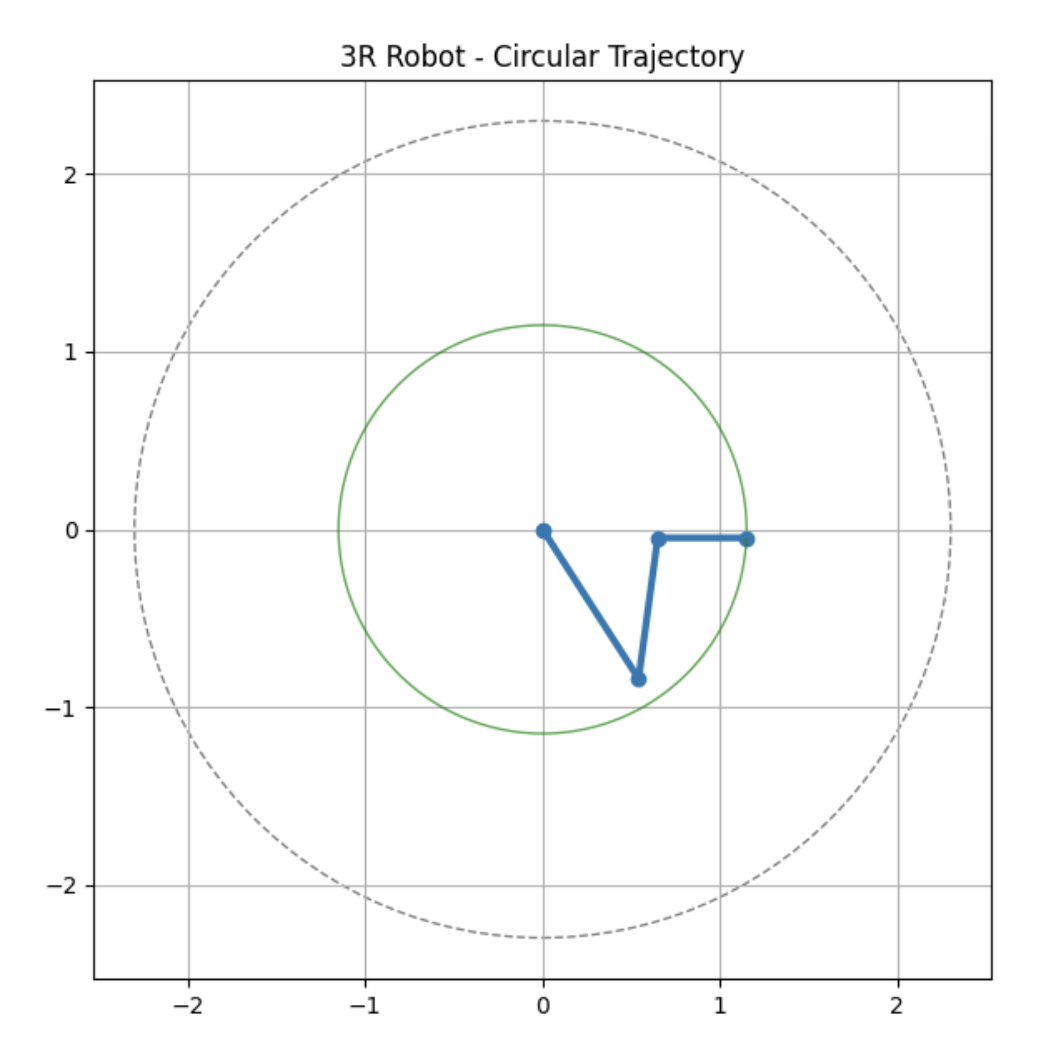

> **Comparison: 2R vs 3R Workspace**

| Feature | 2R Robot | 3R Robot |
|---------|----------|----------|
| Degrees of Freedom | 2 | 3 |
| Workspace Shape | Annular ring | Filled disk (if links allow) |
| Redundancy | None | Yes (infinite solutions for same point) |
| Dexterity | Limited | Higher flexibility |
| Inner hole | $\|L_1 - L_2\|$ | Can be zero if $L_1 \leq L_2 + L_3$ |

In [ ]:
# Visual comparison of 2R and 3R workspaces
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 2R workspace
L1_2r, L2_2r = 1.5, 1.0
theta = np.linspace(-np.pi, np.pi, 80)
t1, t2 = np.meshgrid(theta, theta)
x_2r = L1_2r*np.cos(t1) + L2_2r*np.cos(t1+t2)
y_2r = L1_2r*np.sin(t1) + L2_2r*np.sin(t1+t2)

axes[0].scatter(x_2r.flatten(), y_2r.flatten(), s=1, alpha=0.4, c='blue')
axes[0].add_patch(plt.Circle((0,0), L1_2r+L2_2r, fill=False, color='red', linestyle='--'))
axes[0].add_patch(plt.Circle((0,0), abs(L1_2r-L2_2r), fill=False, color='green', linestyle='--'))
axes[0].set_title(f'2R Workspace: L1={L1_2r}, L2={L2_2r}')
axes[0].set_xlabel('X'); axes[0].set_ylabel('Y')
axes[0].axis('equal'); axes[0].grid(True, alpha=0.3)

# 3R workspace
L1_3r, L2_3r, L3_3r = 1.0, 0.8, 0.7
x_3r, y_3r = compute_workspace_3r_monte_carlo(L1_3r, L2_3r, L3_3r, samples=12000)

axes[1].scatter(x_3r, y_3r, s=1, alpha=0.4, c='purple')
axes[1].add_patch(plt.Circle((0,0), L1_3r+L2_3r+L3_3r, fill=False, color='red', linestyle='--'))
axes[1].set_title(f'3R Workspace: L1={L1_3r}, L2={L2_3r}, L3={L3_3r}')
axes[1].set_xlabel('X'); axes[1].set_ylabel('Y')
axes[1].axis('equal'); axes[1].grid(True, alpha=0.3)

plt.suptitle('2R vs 3R Workspace Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

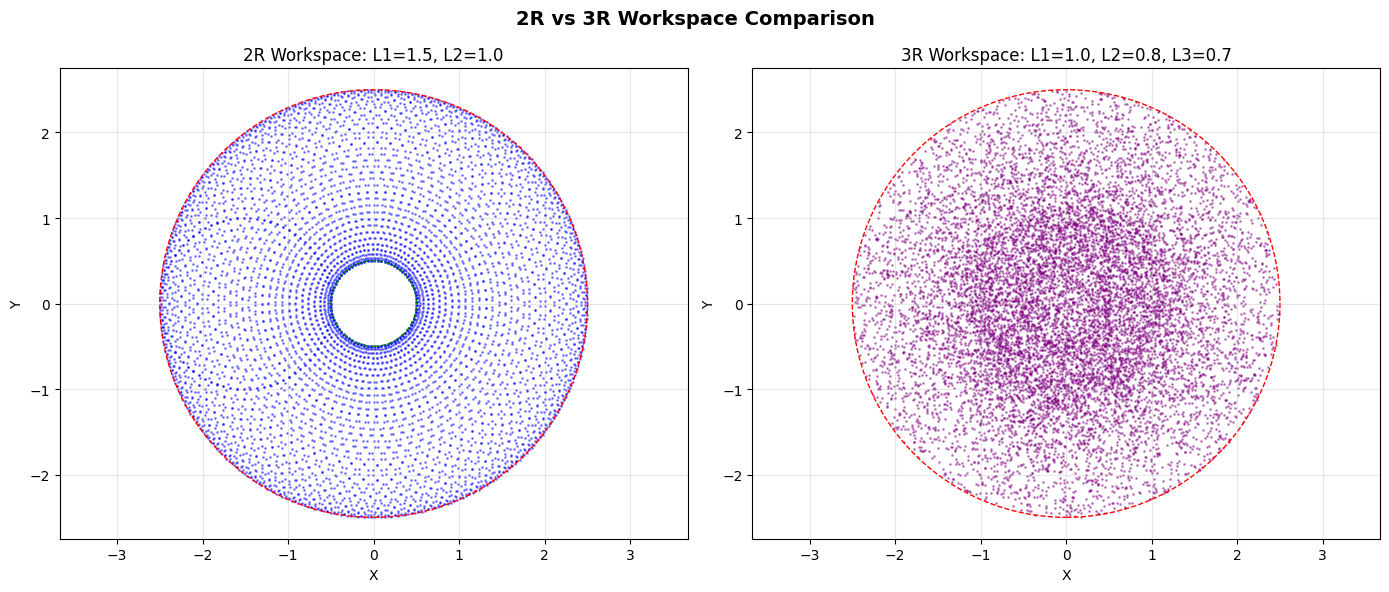

---

## Part C: Workspace Analysis of a PPP (Cartesian) Robot

**Full Form:** PPP = **Prismatic-Prismatic-Prismatic**

A **Cartesian robot** has three prismatic joints along X, Y, Z axes. Simplest to control since joint space = Cartesian space.

**Forward Kinematics:**
$$x = L_1 + d_1, \quad y = L_2 + d_2, \quad z = L_3 + d_3$$

**Workspace:** Rectangular box (no singularities, direct position mapping)

In [ ]:
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

def plot_workspace_multiview(X, Y, Z, title, cmap='viridis'):
    """Plot 3D workspace with multiple views for better understanding."""
    fig = plt.figure(figsize=(15, 5))
    
    colors = np.sqrt(X**2 + Y**2 + Z**2)
    
    # 3D isometric view
    ax1 = fig.add_subplot(131, projection='3d')
    ax1.scatter(X, Y, Z, s=2, alpha=0.4, c=colors, cmap=cmap)
    ax1.set_xlabel('X'); ax1.set_ylabel('Y'); ax1.set_zlabel('Z')
    ax1.set_title('3D View')
    ax1.view_init(elev=25, azim=45)
    
    # Top view (XY plane)
    ax2 = fig.add_subplot(132)
    ax2.scatter(X, Y, s=1, alpha=0.3, c=colors, cmap=cmap)
    ax2.set_xlabel('X'); ax2.set_ylabel('Y')
    ax2.set_title('Top View (XY Plane)')
    ax2.set_aspect('equal')
    ax2.grid(True, alpha=0.3)
    
    # Side view (XZ plane)
    ax3 = fig.add_subplot(133)
    ax3.scatter(X, Z, s=1, alpha=0.3, c=colors, cmap=cmap)
    ax3.set_xlabel('X'); ax3.set_ylabel('Z')
    ax3.set_title('Side View (XZ Plane)')
    ax3.grid(True, alpha=0.3)
    
    fig.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

In [ ]:
# PPP Workspace - sample the 3D box
d1 = np.linspace(0, 2, 10)
d2 = np.linspace(0, 1.5, 10)
d3 = np.linspace(0, 1, 10)
D1, D2, D3 = np.meshgrid(d1, d2, d3)
X, Y, Z = D1.flatten(), D2.flatten(), D3.flatten()

plot_workspace_multiview(X, Y, Z, 'PPP Robot Workspace (Cartesian Box)', cmap='coolwarm')

![ppp](image-1.png)
> **PPP Animation** — Dual view (3D + XY projection) helps visualize the motion pattern. The robot traces a 3D Lissajous curve.

In [ ]:
def animate_3d_with_projection(positions, limits, title, T=5.0, fps=20):
    frames = len(positions)
    
    fig = plt.figure(figsize=(12, 5))
    # 3D view
    ax1 = fig.add_subplot(121, projection='3d')
    ax1.set_xlim(limits[0]); ax1.set_ylim(limits[1]); ax1.set_zlim(limits[2])
    ax1.set_xlabel('X'); ax1.set_ylabel('Y'); ax1.set_zlabel('Z')
    ax1.set_title(f'{title} - 3D')
    line3d, = ax1.plot3D([], [], [], 'b-o', lw=3, markersize=6)
    path3d, = ax1.plot3D([], [], [], 'r-', lw=1, alpha=0.5)
    
    # XY projection (top view)
    ax2 = fig.add_subplot(122)
    ax2.set_xlim(limits[0]); ax2.set_ylim(limits[1])
    ax2.set_xlabel('X'); ax2.set_ylabel('Y')
    ax2.set_title(f'{title} - Top View')
    ax2.set_aspect('equal'); ax2.grid(True, alpha=0.3)
    line2d, = ax2.plot([], [], 'b-o', lw=3, markersize=6)
    path2d, = ax2.plot([], [], 'r-', lw=1, alpha=0.5)
    
    xs, ys, zs = [], [], []
    
    def init():
        line3d.set_data_3d([], [], []); path3d.set_data_3d([], [], [])
        line2d.set_data([], []); path2d.set_data([], [])
        return line3d, path3d, line2d, path2d
    
    def update(i):
        x, y, z = positions[i]
        xs.append(x); ys.append(y); zs.append(z)
        line3d.set_data_3d([0, x], [0, y], [0, z])
        path3d.set_data_3d(xs, ys, zs)
        line2d.set_data([0, x], [0, y])
        path2d.set_data(xs, ys)
        return line3d, path3d, line2d, path2d
    
    ani = animation.FuncAnimation(fig, update, frames=frames, init_func=init, 
                                   interval=1000/fps, blit=False)
    plt.close(fig)
    return HTML(ani.to_jshtml())

t = np.linspace(0, 2*np.pi, 100)
ppp_positions = [(1+0.8*np.sin(ti), 0.75+0.5*np.sin(ti+1), 0.5+0.4*np.sin(ti+2)) for ti in t]

animate_3d_with_projection(ppp_positions, [(-0.5, 2.5), (-0.5, 2), (-0.5, 1.5)], 'PPP Robot')

![ppp-ws](image-2.png)
---

## Part D: Workspace Analysis of an RPP (Cylindrical) Robot

**Full Form:** RPP = **Revolute-Prismatic-Prismatic**

Base rotates ($\theta_1$), then two linear extensions ($d_2$ vertical, $d_3$ radial).

**Forward Kinematics:**
$$x = d_3 \cos(\theta_1), \quad y = d_3 \sin(\theta_1), \quad z = L_1 + d_2$$

**Workspace:** Hollow cylinder (annular if $d_{3,\min} > 0$)

In [ ]:
def rpp_fk(theta1, d2, d3, L1=0.5):
    return d3*np.cos(theta1), d3*np.sin(theta1), L1+d2

In [ ]:
# RPP Workspace - cylindrical shape
L1 = 0.5
theta = np.linspace(-np.pi, np.pi, 40)
d2 = np.linspace(0, 1.5, 12)
d3 = np.linspace(0.3, 1.5, 12)

T, D2, D3 = np.meshgrid(theta, d2, d3)
X, Y, Z = rpp_fk(T.flatten(), D2.flatten(), D3.flatten(), L1)

plot_workspace_multiview(X, Y, Z, 'RPP Robot Workspace (Cylindrical)', cmap='plasma')

![rpp](image-3.png)

> **RPP Animation** — The XY projection shows the circular pattern from base rotation. Height varies independently.

In [ ]:
# RPP Animation - helical path
t = np.linspace(0, 4*np.pi, 120)
rpp_positions = [rpp_fk(ti, 0.75+0.5*np.sin(ti/2), 0.9+0.4*np.cos(ti/3), 0.5) for ti in t]

animate_3d_with_projection(rpp_positions, [(-2, 2), (-2, 2), (0, 2.5)], 'RPP Robot (Cylindrical)')

![rpp-ws](image-4.png)

---

## Part E: Workspace Analysis of an RRP (Spherical) Robot

**Full Form:** RRP = **Revolute-Revolute-Prismatic**

Also called **spherical/polar robot**. Two rotations ($\theta_1$ azimuth, $\theta_2$ elevation) + one extension ($d_3$).

**Forward Kinematics:**
$$
x = d_3 \sin(\theta_2) \cos(\theta_1)
$$
$$
y = d_3 \sin(\theta_2) \sin(\theta_1)
$$
$$
z = L_1 + d_3 \cos(\theta_2)
$$

**Workspace:** Thick spherical shell between $d_{3,\min}$ and $d_{3,\max}$

In [ ]:
def rrp_fk(theta1, theta2, d3, L1=0.5):
    return d3*np.sin(theta2)*np.cos(theta1), d3*np.sin(theta2)*np.sin(theta1), L1+d3*np.cos(theta2)

In [ ]:
# RRP Workspace - spherical shell
L1 = 0.5
theta1 = np.linspace(0, 2*np.pi, 40)
theta2 = np.linspace(0.1, np.pi-0.1, 20)
d3 = np.linspace(0.5, 1.5, 8)

T1, T2, D3 = np.meshgrid(theta1, theta2, d3)
X, Y, Z = rrp_fk(T1.flatten(), T2.flatten(), D3.flatten(), L1)

plot_workspace_multiview(X, Y, Z, 'RRP Robot Workspace (Spherical Shell)', cmap='viridis')

![rrp](image-5.png)

> **RRP Animation** — Spiral trajectory on a spherical surface. XY projection reveals the complex pattern created by two rotations.

In [ ]:
# RRP Animation - spiral on sphere
t = np.linspace(0, 4*np.pi, 150)
rrp_positions = [rrp_fk(ti, np.pi/3+(np.pi/4)*np.sin(ti/2), 1.0+0.3*np.cos(ti/1.5), 0.5) for ti in t]

animate_3d_with_projection(rrp_positions, [(-2, 2), (-2, 2), (0, 2.5)], 'RRP Robot (Spherical)')

![rrp-ws](image-6.png)

---

### Workspace Comparison

| Robot | Full Form | Workspace | Best For |
|-------|-----------|-----------|----------|
| **2R** | Revolute-Revolute | Annular ring (2D) | Drawing, SCARA |
| **3R** | Revolute-Revolute-Revolute | Full disk (2D) | Flexible planar tasks |
| **PPP** | Prismatic-Prismatic-Prismatic | Box (3D) | CNC, 3D printers |
| **RPP** | Revolute-Prismatic-Prismatic | Cylinder (3D) | Welding, assembly |
| **RRP** | Revolute-Revolute-Prismatic | Sphere (3D) | Spray painting |
